#### 1

In [134]:
import os
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from utils.timefeatures import time_features

import warnings
warnings.filterwarnings('ignore')

class Dataset_ETT_hour(Dataset):
    def __init__(self, root_path='./Dataset/', flag='train', size=None, 
                 features='S', data_path='ETTh1.csv', 
                 target='OT', scale=True, timeenc=0, freq='h'):
        # size [seq_len, label_len, pred_len]
        # info
        if size == None:
            self.seq_len = 24*4*4
            self.label_len = 24*4
            self.pred_len = 24*4
        else:
            self.seq_len = size[0]
            self.label_len = size[1]
            self.pred_len = size[2]
        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train':0, 'val':1, 'test':2}
        self.set_type = type_map[flag]
        
        self.features = features
        self.target = target
        self.scale = scale
        self.timeenc = timeenc
        self.freq = freq
        
        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler()
        df_raw = pd.read_csv(os.path.join(self.root_path,
                                          self.data_path))

        border1s = [0, 12 * 30 * 24 - self.seq_len, 12 * 30 * 24 + 4 * 30 * 24 - self.seq_len]
        border2s = [12 * 30 * 24, 12 * 30 * 24 + 4 * 30 * 24, 12 * 30 * 24 + 8 * 30 * 24]
        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]
        
        if self.features=='M' or self.features=='MS':
            cols_data = df_raw.columns[1:]
            df_data = df_raw[cols_data]
        elif self.features=='S':
            df_data = df_raw[[self.target]]

        if self.scale:
            train_data = df_data[border1s[0]:border2s[0]]
            self.scaler.fit(train_data.values)
            data = self.scaler.transform(df_data.values)
        else:
            data = df_data.values
            
        df_stamp = df_raw[['date']][border1:border2]
        df_stamp['date'] = pd.to_datetime(df_stamp.date)
        if self.timeenc == 0:
            df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
            df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
            df_stamp['weekday'] = df_stamp.date.apply(lambda row: row.weekday(), 1)
            df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
            data_stamp = df_stamp.drop(['date'], axis=1).values
        elif self.timeenc == 1:
            data_stamp = time_features(pd.to_datetime(df_stamp['date'].values), freq=self.freq)
            data_stamp = data_stamp.transpose(1, 0)

        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]
        self.data_stamp = data_stamp
    
    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len 
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.data_x[s_begin:s_end]
        seq_y = self.data_y[r_begin:r_end]
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark
    
    def __len__(self):
        return len(self.data_x) - self.seq_len - self.pred_len + 1

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)
    
class Dataset_Custom(Dataset):
    def __init__(self, root_path='./Dataset/', flag='train', size=None,
                 features='S', data_path='ETTh1.csv',
                 target='OT', scale=True, timeenc=0, freq='h'):
        # size [seq_len, label_len, pred_len]
        # info
        if size == None:
            self.seq_len = 24 * 4 * 4
            self.label_len = 24 * 4
            self.pred_len = 24 * 4
        else:
            self.seq_len = size[0]
            self.label_len = size[1]
            self.pred_len = size[2]
        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        self.scale = scale
        self.timeenc = timeenc
        self.freq = freq

        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler()
        df_raw = pd.read_csv(os.path.join(self.root_path,
                                          self.data_path))

        '''
        df_raw.columns: ['date', ...(other features), target feature]
        '''
        cols = list(df_raw.columns)
        cols.remove(self.target)
        cols.remove('date')
        df_raw = df_raw[['date'] + cols + [self.target]]
        # print(cols)
        num_train = int(len(df_raw) * 0.7)
        num_test = int(len(df_raw) * 0.2)
        num_vali = len(df_raw) - num_train - num_test
        border1s = [0, num_train - self.seq_len, len(df_raw) - num_test - self.seq_len]
        border2s = [num_train, num_train + num_vali, len(df_raw)]
        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]

        if self.features == 'M' or self.features == 'MS':
            cols_data = df_raw.columns[1:]
            df_data = df_raw[cols_data]
        elif self.features == 'S':
            df_data = df_raw[[self.target]]

        if self.scale:
            train_data = df_data[border1s[0]:border2s[0]]
            self.scaler.fit(train_data.values)
            # print(self.scaler.mean_)
            # exit()
            data = self.scaler.transform(df_data.values)
        else:
            data = df_data.values

        df_stamp = df_raw[['date']][border1:border2]
        df_stamp['date'] = pd.to_datetime(df_stamp.date)
        if self.timeenc == 0:
            df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
            df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
            df_stamp['weekday'] = df_stamp.date.apply(lambda row: row.weekday(), 1)
            df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
            data_stamp = df_stamp.drop(['date'], axis=1).values
        elif self.timeenc == 1:
            data_stamp = time_features(pd.to_datetime(df_stamp['date'].values), freq=self.freq)
            data_stamp = data_stamp.transpose(1, 0)

        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]
        self.data_stamp = data_stamp

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.data_x[s_begin:s_end]
        seq_y = self.data_y[r_begin:r_end]
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark

    def __len__(self):
        return len(self.data_x) - self.seq_len - self.pred_len + 1

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)


In [135]:
def data_provider(config):
    if config.dataset == "ETTh1.csv" or config.dataset == "ETTh2.csv":
        train_dataset = Dataset_ETT_hour(
            flag='train',
            features='M', # M: multivariate, S: univariate
            size=[config.seq_len, config.label_len, config.pred_len],
            data_path=config.dataset
        )

        test_dataset = Dataset_ETT_hour(
            flag='test',
            features='M', # M: multivariate, S: univariate
            size=[config.seq_len, config.label_len, config.pred_len],
            data_path=config.dataset
        )
        
        vali_dataset = Dataset_ETT_hour(
            flag='val',
            features='M', # M: multivariate, S: univariate
            size=[config.seq_len, config.label_len, config.pred_len],
            data_path=config.dataset
        )
    elif config.dataset == "electricity.csv":
        train_dataset = Dataset_Custom(
            flag='train',
            features='M', # M: multivariate, S: univariate
            size=[config.seq_len, config.label_len, config.pred_len],
            data_path=config.dataset
        )

        test_dataset = Dataset_Custom(
            flag='test',
            features='M', # M: multivariate, S: univariate
            size=[config.seq_len, config.label_len, config.pred_len],
            data_path=config.dataset
        )
        
        vali_dataset = Dataset_Custom(
            flag='val',
            features='M', # M: multivariate, S: univariate
            size=[config.seq_len, config.label_len, config.pred_len],
            data_path=config.dataset
        )

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=10,
        drop_last=True,
    )

    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=10,
        drop_last=False
    )

    vali_loader = DataLoader(
        dataset=vali_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=10,
        drop_last=True,
        
    )

    return train_dataset, train_loader, test_dataset, test_loader, vali_dataset, vali_loader

In [136]:
from models import Linear, DMSLinear, LSTM, SparseTSF, SparseTSF_Transfrom, FITS, DLinear, PatchTST, SegTSF, Sample
from utils.metric import metric
from utils.tools import EarlyStopping, adjust_learning_rate

import time
import matplotlib.pyplot as plt
import torch
from torch.optim import lr_scheduler 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
path = os.path.join('./checkpoints/', 'ETT_hour_linear.pth')
if not os.path.exists(path):
    os.makedirs(path)

In [137]:
def vali(model, vali_loader, criterion, device, pred_len, label_len):
    total_loss = []
    model.eval()
    with torch.no_grad():
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(vali_loader):
            
            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float()
            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            outputs = model(batch_x)
            outputs = outputs[:, -pred_len:, :]
            batch_y = batch_y[:, -pred_len:, :].to(device)

            pred = outputs.detach().cpu()
            true = batch_y.detach().cpu()

            loss = criterion(pred, true)

            total_loss.append(loss)
            
    total_loss = np.average(total_loss)
    model.train()
    return total_loss

def train(config, train_loader, vali_loader, test_loader):
    model_dict = {
        'Linear': Linear,
        'DMSLinear': DMSLinear,
        'LSTM': LSTM,
        'SparseTSF': SparseTSF,
        'SparseTSF_Transfrom': SparseTSF_Transfrom,
        'Sample' : Sample,
        'FITS' : FITS,
        'DLinear' : DLinear,
        'PatchTST' : PatchTST,
        'SegTSF' : SegTSF,
    }
    model = model_dict[config.model].Model(config).float().to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print('Model total parameters:', total_params)
    gc.collect()

    # macs, params = get_model_complexity_info(model,
    #                                         (config.seq_len, config.channels),
    #                                         as_strings=True,
    #                                         print_per_layer_stat=False,
    #                                         verbose=False)
    # print('Computational complexity: ' + macs)
    # print('Number of parameters: ' + params)
    
    train_steps = len(train_loader)
    early_stopping = EarlyStopping(patience=config.patience, verbose=True)

    if config.criterion == 'MSE':
        criterion = torch.nn.MSELoss()
    elif config.criterion == 'MAE':
        criterion = torch.nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    scheduler = lr_scheduler.OneCycleLR(optimizer = optimizer,
                                        steps_per_epoch = train_steps,
                                        pct_start = 0.3,
                                        epochs = config.epochs,
                                        max_lr = config.learning_rate,)

    for epoch in range(config.epochs):
        iter_count = 0
        train_loss = []
        
        model.train()
        epoch_time = time.time()
        max_memory = 0
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            iter_count += 1
            optimizer.zero_grad()
            
            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)
            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            outputs = model(batch_x)
            outputs = outputs[:, -config.pred_len:, :]
            batch_y = batch_y[:, -config.pred_len:, :].to(device)

            loss = criterion(outputs, batch_y)
            train_loss.append(loss.item())
            
            if (i + 1) % 100 == 0:
                time_now = time.time()
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((config.epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
            
            loss.backward()
            optimizer.step()
            
            current_memory = torch.cuda.max_memory_allocated() / 1024 ** 2
            max_memory = max(max_memory, current_memory)
            
        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        vali_loss = vali(model, vali_loader, criterion, device, config.pred_len, config.label_len)
        test_loss = vali(model, test_loader, criterion, device, config.pred_len, config.label_len)

        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Vali Loss: {3:.7f} Test Loss: {4:.7f}".format(
            epoch + 1, train_steps, train_loss, vali_loss, test_loss))
        early_stopping(vali_loss, model, path)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        adjust_learning_rate(optimizer, scheduler, epoch + 1, config)
        print('=========================================')
        print(f"Max Memory (MB): {max_memory}")
    # best_model_path = path + '/' + 'checkpoint.pth'
    # model.load_state_dict(torch.load(best_model_path))
    
    return model

import os, time, gc
import torch, numpy as np
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info

def test(config, test_dataset, test_loader, model):
    model.to(device).eval()
    os.makedirs("./img", exist_ok=True)
    folder_path = f'./results/{time.time():.0f}/'
    os.makedirs(folder_path, exist_ok=True)

    # 누적 대신 합/개수 방식(예: MSE/MAE)
    n_samples = 0
    sum_abs = 0.0
    sum_sq  = 0.0

    # 필요 시 상관계수 등 위해서만 소규모 샘플 보관
    sample_plot_done = False

    begin_time = time.time()
    with torch.inference_mode():
        for i, (bx, by, bxm, bym) in enumerate(test_loader):
            bx = bx.float().to(device, non_blocking=True)
            by = by.float().to(device, non_blocking=True)

            out = model(bx)
            # 출력 길이 방어적 슬라이스
            pred_len = min(config.pred_len, out.shape[1], by.shape[1])
            out = out[:, -pred_len:, :]
            tgt = by[:, -pred_len:, :]

            # 메트릭 즉시 업데이트(여기서는 MSE/MAE 예시)
            diff = (out - tgt).detach()
            sum_abs += diff.abs().sum().item()
            sum_sq  += (diff ** 2).sum().item()
            n_samples += diff.numel()

            # 필요하면 샘플 1회만 플롯
            if (i % 20 == 0) and (not sample_plot_done):
                x_cpu  = bx.detach().cpu()
                y_cpu  = tgt.detach().cpu()
                o_cpu  = out.detach().cpu()
                # 채널 존재/인덱스 방어
                ch = min(x_cpu.shape[-1]-1, 0)
                # 입력 구간 + 예측 구간 이어 붙이기 (1D)
                gt = np.concatenate((x_cpu[0, :, ch].numpy(), y_cpu[0, :, ch].numpy()), axis=0)
                pd = np.concatenate((x_cpu[0, :, ch].numpy(), o_cpu[0, :, ch].numpy()), axis=0)
                plt.figure(figsize=(12, 5))
                plt.plot(gt, label='true')
                plt.plot(pd, label='pred')
                plt.legend()
                plt.savefig(f'./img/{config.model}.png')
                plt.close()
                sample_plot_done = True

            # 루프 말미 GC(가볍게)
            del bx, by, bxm, bym, out, tgt, diff
            if torch.cuda.is_available():
                torch.cuda.empty_cache()  # ← 루프 내 상시호출은 지양. 필요하면 "간헐적"으로만
        # end for

    elapsed = time.time() - begin_time
    mae = sum_abs / n_samples
    mse = sum_sq  / n_samples
    rmse = np.sqrt(mse)

    # 결과 출력
    print("==================================================")
    print(f"mse:{mse:.6f}, mae:{mae:.6f}, rmse:{rmse:.6f}, "
          f"ms/sample:{(elapsed*1000)/len(test_dataset):.3f}")
    print(f"inference time: {elapsed:.3f}s")

    # 마지막에만 캐시 정리
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
# def test(config, test_dataset, test_loader, model):
#     torch.cuda.synchronize()
    
#     preds = []
#     trues = []
#     inputx = []
#     folder_path = './test_results/' + str(time.time()) + '/'
#     if not os.path.exists(folder_path):
#         os.makedirs(folder_path)

#     begin_time = time.time()
#     model.eval()
#     with torch.no_grad():
#         for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(test_loader):
#             if torch.cuda.is_available():
#                 torch.cuda.empty_cache()
#             batch_x = batch_x.float().to(device)
#             batch_y = batch_y.float().to(device)

#             batch_x_mark = batch_x_mark.float().to(device)
#             batch_y_mark = batch_y_mark.float().to(device)

#             outputs = model(batch_x)
#             outputs = outputs[:, -config.pred_len:, :]
#             batch_y = batch_y[:, -config.pred_len:, :].to(device)
#             outputs = outputs.detach().cpu().numpy()
#             batch_y = batch_y.detach().cpu().numpy()

#             pred = outputs 
#             true = batch_y 
            
#             preds.append(pred)
#             trues.append(true)
#             inputx.append(batch_x.detach().cpu().numpy())
#             if i % 20 == 0:
#                 input = batch_x.detach().cpu().numpy()
#                 gt = np.concatenate((input[0, :, -1], true[0, :, -1]), axis=0)
#                 pd = np.concatenate((input[0, :, -1], pred[0, :, -1]), axis=0)
#                 plt.figure(figsize=(15, 7))
#                 plt.plot(gt, label='true')
#                 plt.plot(pd, label='pred')
#                 plt.legend()
#                 plt.savefig('./img/' + f'{config.model}.png')
#                 plt.close()
            
#     ms = (time.time() - begin_time) * 1000 / len(test_dataset)
    
#     preds = np.concatenate(preds, axis=0)
#     trues = np.concatenate(trues, axis=0)
#     inputx = np.concatenate(inputx, axis=0)

#     preds = preds.reshape(-1, preds.shape[-2], preds.shape[-1])
#     trues = trues.reshape(-1, trues.shape[-2], trues.shape[-1])
#     inputx = inputx.reshape(-1, inputx.shape[-2], inputx.shape[-1])
    
#     folder_path = './results/' + str(time.time()) + '/'
#     if not os.path.exists(folder_path):
#         os.makedirs(folder_path)
        
#     mae, mse, rmse, mape, mspe, rse, corr = metric(preds, trues)
#     print("==================================================")
#     print('mse:{}, mae:{}, ms/sample:{}'.format(mse, mae, ms))
#     torch.cuda.synchronize()
#     end_time = time.time()
#     print("inference time: {}".format(end_time - begin_time))

#     return

#### 2

In [138]:
import random
import torch
from types import SimpleNamespace

seed = 2023
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)

##################################
# 하이퍼파라미터 설정
config = SimpleNamespace(
    model='SegTSF',   # e.g., 'Linear', 'DMSLinear', 'SparseTSF_Transfrom', 'SparseTSF'
    dataset="ETTh1.csv", # ETTh1, ETTh2, traffic, electricity, traffic
    channels=7, # ETT = 7 / electricity = 321 / traffic = 862
    period_len=24,
    seq_len=720,
    pred_len=96,
    seg_len_x=6,  
    seg_len_y=2,
    batch_size=256, # ETT = 256 / electricity & traffic = 128
    learning_rate=0.02, # ETTh1 & electricity = 0.02 / ETTh2 & traffic = 0.03 /      
    label_len=0,                          
    lradj='type3', 
    epochs=30,               
    patience=5,
    criterion='MSE',  # Options: 'MSE', 'MAE'
)

# 실행 코드
train_dataset, train_loader, test_dataset, test_loader, vali_dataset, vali_loader = data_provider(config)

In [139]:
if torch.cuda.is_available():
        torch.cuda.empty_cache()
model = train(config, train_loader, vali_loader, test_loader) 
test(config, test_dataset, test_loader, model)

Model total parameters: 623
Epoch: 1 cost time: 0.9987504482269287
Epoch: 1, Steps: 30 | Train Loss: 0.6531998 Vali Loss: 1.4011456 Test Loss: 0.7184803
Validation loss decreased (inf --> 1.401146).  Saving model ...
Updating learning rate to 0.02
Max Memory (MB): 180.48828125
Epoch: 2 cost time: 0.6704037189483643
Epoch: 2, Steps: 30 | Train Loss: 0.4902653 Vali Loss: 0.8448009 Test Loss: 0.4104594
Validation loss decreased (1.401146 --> 0.844801).  Saving model ...
Updating learning rate to 0.02
Max Memory (MB): 180.48828125
Epoch: 3 cost time: 0.694176435470581
Epoch: 3, Steps: 30 | Train Loss: 0.3783514 Vali Loss: 0.7436284 Test Loss: 0.3691496
Validation loss decreased (0.844801 --> 0.743628).  Saving model ...
Updating learning rate to 0.02
Max Memory (MB): 180.48828125
Epoch: 4 cost time: 0.6457259654998779
Epoch: 4, Steps: 30 | Train Loss: 0.3597898 Vali Loss: 0.7304191 Test Loss: 0.3531122
Validation loss decreased (0.743628 --> 0.730419).  Saving model ...
Updating learning r

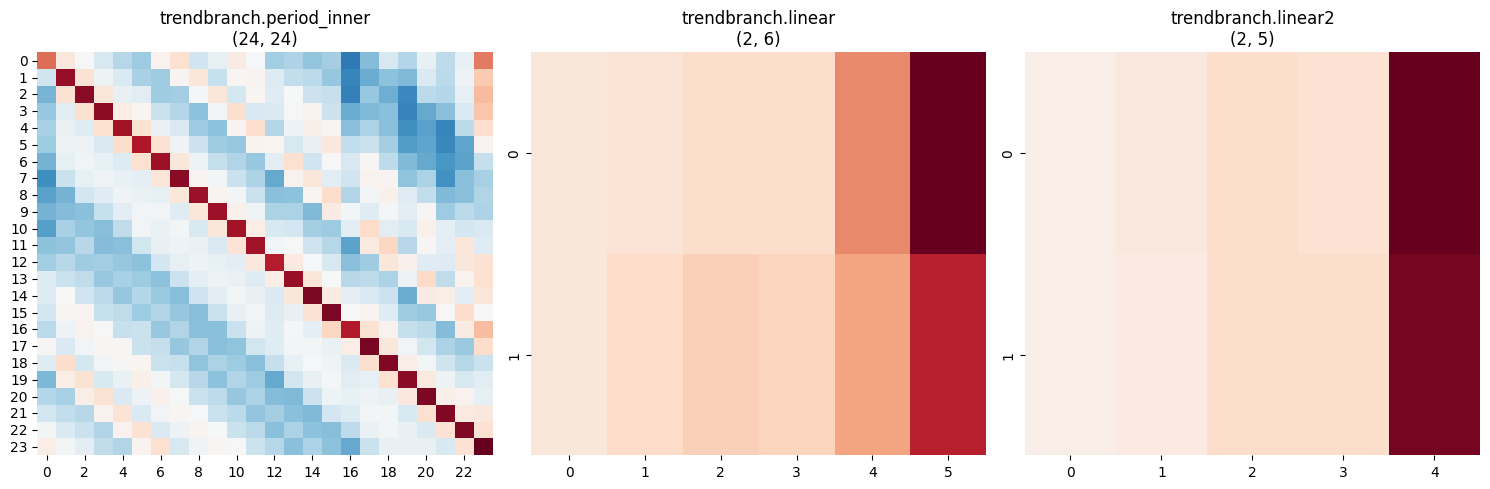

In [140]:
%matplotlib inline
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

def plot_linear_weights_clean(model):
    # 1. 실제 Linear 레이어 객체만 딱 한 번씩 추출
    linear_layers = []
    seen_params = set()
    
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear) and m.weight not in seen_params:
            linear_layers.append((name, m))
            seen_params.add(m.weight)

    if not linear_layers: return

    # 2. 시각화 (한 줄에 모든 레이어 표시)
    n = len(linear_layers)
    fig, axes = plt.subplots(1, n, figsize=(min(5*n, 20), 5))
    if n == 1: axes = [axes]

    for i, (name, layer) in enumerate(linear_layers):
        weights = layer.weight.detach().cpu().numpy()
        sns.heatmap(weights, ax=axes[i], cmap='RdBu_r', center=0, cbar=False)
        axes[i].set_title(f"{name}\n{weights.shape}")

    plt.tight_layout()
    plt.show()

# 루프 밖에서 호출하세요!
plot_linear_weights_clean(model)

가중치 계산 중...완료.


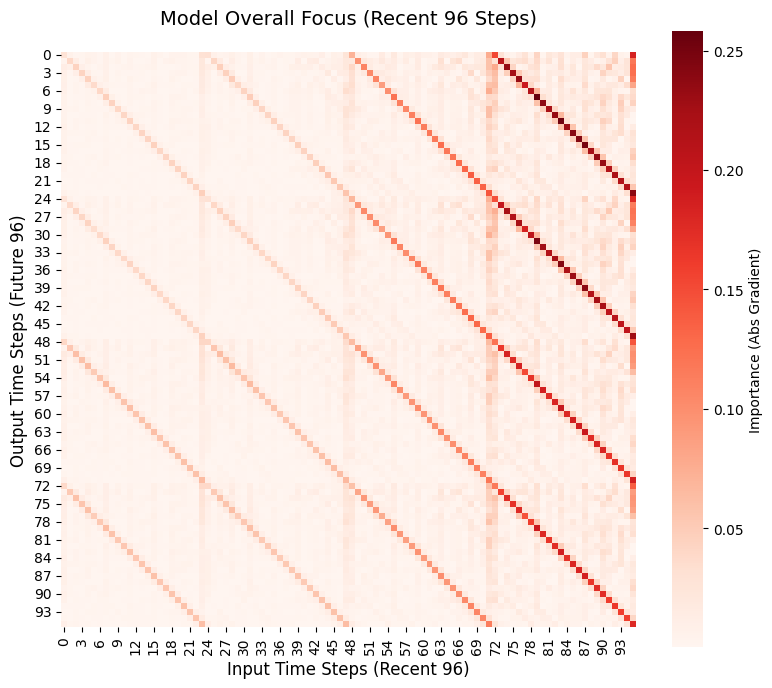

In [141]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_96x96_square_forced(model, configs):
    model.eval()
    device = next(model.parameters()).device
    
    # 1. 입력 텐서 생성 (기울기 추적 활성화)
    input_tensor = torch.randn(1, configs.seq_len, configs.channels).to(device).requires_grad_(True)
    
    # 2. 모델 실행
    output_tensor = model(input_tensor)
    
    full_weights = []
    
    # 3. 영향력 계산 (Gradient 방식)
    print("가중치 계산 중...", end="")
    for i in range(configs.pred_len):
        if input_tensor.grad is not None:
            input_tensor.grad.zero_()
            
        grad_output = torch.zeros_like(output_tensor).to(device)
        grad_output[0, i, 0] = 1
        
        output_tensor.backward(gradient=grad_output, retain_graph=True)
        
        if input_tensor.grad is not None:
            influence = input_tensor.grad[0, :, 0].abs().detach().cpu().numpy()
            full_weights.append(influence)
        else:
            full_weights.append(np.zeros(configs.seq_len))
    print("완료.")
            
    full_matrix = np.array(full_weights) # (96, 720)

    # 4. 최근 96개 시점 슬라이싱 (96x96 데이터 만들기)
    square_matrix = full_matrix[:, -96:] 

    # 5. 시각화 (정사각형 강제 적용)
    plt.figure(figsize=(8, 8)) # 캔버스 크기 정사각형 설정
    
    # [핵심 수정] square=True 옵션 추가
    # 이 옵션이 각 셀을 정사각형으로 만들어 전체 비율을 고정합니다.
    ax = sns.heatmap(square_matrix, cmap='Reds', 
                     cbar_kws={'label': 'Importance (Abs Gradient)', 'shrink': 0.8},
                     square=True)
    
    plt.title("Model Overall Focus (Recent 96 Steps)", fontsize=14, pad=20)
    plt.xlabel("Input Time Steps (Recent 96)", fontsize=12)
    plt.ylabel("Output Time Steps (Future 96)", fontsize=12)
    
    # 여백 자동 조정
    plt.tight_layout()
    plt.show()

# 실행
visualize_96x96_square_forced(model, config)

In [142]:
# seg_len_x=[1,2,3,5,6,10,15,30]  
# seg_len_y=[1,2,3,5,6,10,15,30]  

# for sx in seg_len_x:
#     for sy in seg_len_y:
#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()
#         config.seg_len_x = sx
#         config.seg_len_y = sy
#         print(f"seg_len_x: {sx}, seg_len_y: {sy}")
#         model = train(config, train_loader, vali_loader, test_loader) 
#         test(config, test_dataset, test_loader, model)